In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score, auc

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datetime import datetime

def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)

## Lets do it for synthetic multiple

In [3]:
import re

def extract_aml_urls(log_file_path):
    # Initialize a list to store the extracted URLs
    aml_urls = []

    # Define a regular expression to match the log entries containing AML URLs
    aml_url_pattern = re.compile(r'AML URL: (https://ml\.azure\.com/runs/[\w\-\?&=/]+)')

    # Open and read the log file
    with open(log_file_path, 'r') as file:
        for line in file:
            match = aml_url_pattern.search(line)
            if match:
                aml_urls.append(match.group(1))

    return aml_urls

In [6]:
mia_methods=("jaccard_25", "embedding_25", "ngram_2")
multiples = (1, 2, 4, 8)

## (1) Let's first do sst-2

In [5]:
DATASET = 'sst2'

# Extract the AML URLs
aml_urls = extract_aml_urls(f'../job_launch_outputs/synthetic_multiples_all_mias_{DATASET}.txt')
aml_urls

['https://ml.azure.com/runs/olive_insect_n1m760f17z?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/amiable_pasta_v4ktpdc96y?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/affable_boot_3mbl2k13jf?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/loyal_cat_48xczypk3z?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/loyal_basil_d785vps392?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41a

In [10]:
method_to_aucs = {}

i = 0
for j, multiple in enumerate(multiples):
    for method in mia_methods:
        job_name = f'multiple_{multiple}_synthetic_{method}'
        print(f"Processing {job_name}")
        performance = compute_performance_from_url(aml_urls[i])
        if j == 0:
            method_to_aucs[method] = [performance['auc']]
        else:
            method_to_aucs[method].append(performance['auc'])
        i += 1

Processing multiple_1_synthetic_jaccard_25


AUC: 0.5473552816352005, TPR@0.01: 0.01775147928994083, TPR@0.05: 0.0670611439842209, TPR@0.1: 0.11439842209072978
Processing multiple_1_synthetic_embedding_25
AUC: 0.5295477913671081, TPR@0.01: 0.023668639053254437, TPR@0.05: 0.06903353057199212, TPR@0.1: 0.1282051282051282
Processing multiple_1_synthetic_ngram_2
AUC: 0.6163848114230388, TPR@0.01: 0.03155818540433925, TPR@0.05: 0.10453648915187377, TPR@0.1: 0.20907297830374755
Processing multiple_2_synthetic_jaccard_25
AUC: 0.5412620873691244, TPR@0.01: 0.011834319526627219, TPR@0.05: 0.0611439842209073, TPR@0.1: 0.1282051282051282
Processing multiple_2_synthetic_embedding_25
AUC: 0.5217142559941748, TPR@0.01: 0.01972386587771203, TPR@0.05: 0.055226824457593686, TPR@0.1: 0.13806706114398423
Processing multiple_2_synthetic_ngram_2
AUC: 0.6332401150625522, TPR@0.01: 0.05325443786982249, TPR@0.05: 0.14792899408284024, TPR@0.1: 0.21104536489151873
Processing multiple_4_synthetic_jaccard_25
AUC: 0.5748726750443087, TPR@0.01: 0.027613412228

In [11]:
method_to_aucs

{'jaccard_25': [0.5473552816352005,
  0.5412620873691244,
  0.5748726750443087,
  0.5717440618361199],
 'embedding_25': [0.5295477913671081,
  0.5217142559941748,
  0.5560809918744074,
  0.5537525354969575],
 'ngram_2': [0.6163848114230388,
  0.6332401150625522,
  0.6793651555704918,
  0.7383607187008654]}

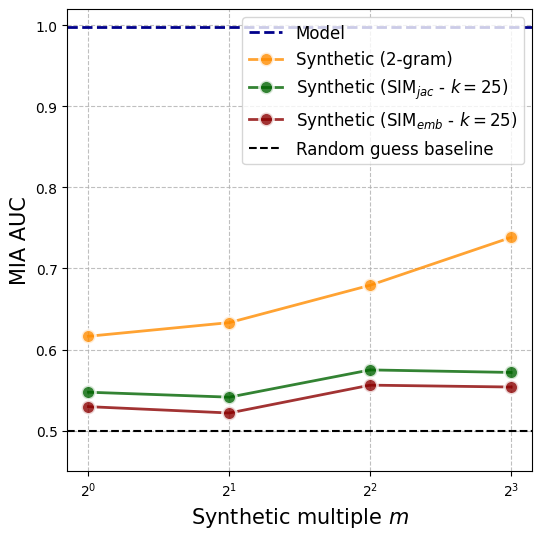

In [14]:
methods = ['ngram_2', 'jaccard_25', 'embedding_25']
labels = ['Synthetic (2-gram)', r'Synthetic ($\text{SIM}_{jac}$ - $k=25$)', r'Synthetic ($\text{SIM}_{emb}$ - $k=25$)']
colors = ['darkorange', 'darkgreen', 'darkred']

plt.figure(figsize=(6, 6))
plt.axhline(y=0.998, color='darkblue', linestyle='--', linewidth = 2, alpha=1, label = 'Model')
for i, method in enumerate(methods):
    plt.plot([1, 2, 4, 8], method_to_aucs[method], '-o', alpha=0.8, label=labels[i], color = colors[i],
              markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white')
plt.xscale('log', base=2)
plt.xlabel(r'Synthetic multiple $m$', fontsize=15)
plt.ylabel('MIA AUC', fontsize=15)
plt.grid(True, which="both", ls="--", alpha=0.8)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=1.0, label = 'Random guess baseline')
plt.legend(fontsize=12)
plt.ylim(0.45, 1.02)
plt.savefig(f'figures/synthetic_multiple_{DATASET}.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## (2) Let's repeat this for AgNews

In [15]:
DATASET = 'agnews'

# Extract the AML URLs
aml_urls = extract_aml_urls(f'../job_launch_outputs/synthetic_multiples_all_mias_{DATASET}.txt')
aml_urls

['https://ml.azure.com/runs/tidy_bean_d3zdby70l2?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/calm_ghost_bd0hkpv7p3?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/sharp_sprout_5bvp7vxp64?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/shy_bridge_t6bj4t3086?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/bold_camera_lnxlj10ct1?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91a

In [16]:
method_to_aucs = {}

i = 0
for j, multiple in enumerate(multiples):
    for method in mia_methods:
        job_name = f'multiple_{multiple}_synthetic_{method}'
        print(f"Processing {job_name}")
        performance = compute_performance_from_url(aml_urls[i])
        if j == 0:
            method_to_aucs[method] = [performance['auc']]
        else:
            method_to_aucs[method].append(performance['auc'])
        i += 1

Processing multiple_1_synthetic_jaccard_25
AUC: 0.5516161167588848, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.0631163708086785, TPR@0.1: 0.11439842209072978
Processing multiple_1_synthetic_embedding_25
AUC: 0.5061352024996899, TPR@0.01: 0.015779092702169626, TPR@0.05: 0.04930966469428008, TPR@0.1: 0.07692307692307693
Processing multiple_1_synthetic_ngram_2
AUC: 0.644426307556281, TPR@0.01: 0.029585798816568046, TPR@0.05: 0.1282051282051282, TPR@0.1: 0.2603550295857988
Processing multiple_2_synthetic_jaccard_25
AUC: 0.5530163912126778, TPR@0.01: 0.015779092702169626, TPR@0.05: 0.05325443786982249, TPR@0.1: 0.13609467455621302
Processing multiple_2_synthetic_embedding_25
AUC: 0.5498957795727963, TPR@0.01: 0.01972386587771203, TPR@0.05: 0.08284023668639054, TPR@0.1: 0.13609467455621302
Processing multiple_2_synthetic_ngram_2
AUC: 0.6429380158511069, TPR@0.01: 0.04339250493096647, TPR@0.05: 0.16173570019723865, TPR@0.1: 0.2465483234714004
Processing multiple_4_synthetic_jaccard_25
AUC: 0

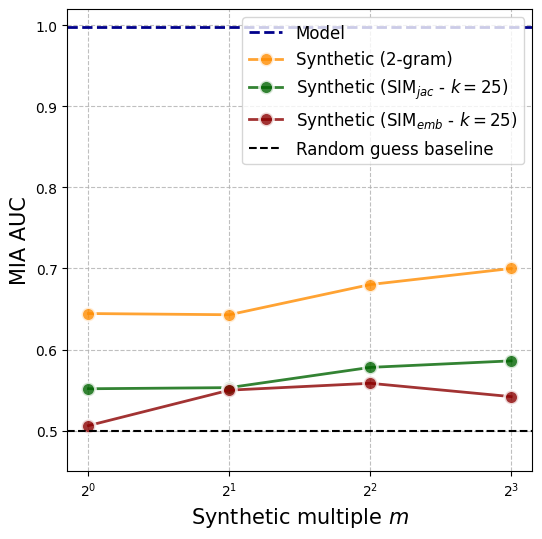

In [17]:
methods = ['ngram_2', 'jaccard_25', 'embedding_25']
labels = ['Synthetic (2-gram)', r'Synthetic ($\text{SIM}_{jac}$ - $k=25$)', r'Synthetic ($\text{SIM}_{emb}$ - $k=25$)']
colors = ['darkorange', 'darkgreen', 'darkred']

plt.figure(figsize=(6, 6))
plt.axhline(y=0.998, color='darkblue', linestyle='--', linewidth = 2, alpha=1, label = 'Model')
for i, method in enumerate(methods):
    plt.plot([1, 2, 4, 8], method_to_aucs[method], '-o', alpha=0.8, label=labels[i], color = colors[i],
              markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white')
plt.xscale('log', base=2)
plt.xlabel(r'Synthetic multiple $m$', fontsize=15)
plt.ylabel('MIA AUC', fontsize=15)
plt.grid(True, which="both", ls="--", alpha=0.8)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=1.0, label = 'Random guess baseline')
plt.legend(fontsize=12)
plt.ylim(0.45, 1.02)
plt.savefig(f'figures/synthetic_multiple_{DATASET}.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()